## Instalasi Dependensi


In [21]:
!pip install pyspark pandas matplotlib seaborn

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Scalable Market Basket Analysis Using MapReduce and FP-Growth with PySpark

**Dataset:** Instacart (order_id, product_name)  
**Teknologi:** PySpark (Spark MLlib), MapReduce, Pandas, Matplotlib, Seaborn

---

## 1. Arsitektur Sistem & Flowchart

Sistem ini dirancang untuk memproses data transaksi dalam skala besar menggunakan prinsip **Distributed Computing**.

### Arsitektur:
1. **Data Layer**: Mengambil data CSV Instacart yang telah di-preprocess.
2. **Processing Layer (MapReduce)**: Mentransformasi data mentah menjadi format transaksi (list of items per order).
3. **Mining Layer (FP-Growth)**: Menemukan *Frequent Itemsets* tanpa perlu membuat kandidat secara eksplisit (lebih cepat dari Apriori).
4. **Inference Layer**: Menghasilkan *Association Rules* dan sistem rekomendasi.

### Konsep MapReduce:
- **Mapper**: Mengambil baris `(order_id, product_name)` dan mengeluarkan pasangan Key-Value.
- **Shuffle**: Mengelompokkan semua produk berdasarkan `order_id` yang sama di seluruh core/node.
- **Reducer**: Menggabungkan list produk menjadi satu array transaksi tunggal per `order_id`.

## 2. Inisialisasi Environment
Kita akan menggunakan `local[*]` untuk memastikan semua core CPU pada komputer Anda digunakan secara maksimal.

In [ ]:
import os
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, concat_ws, size
from pyspark.ml.fpm import FPGrowth
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi
DATA_PATH = r"/content/drive/MyDrive/BigData/market_basket_dataset.csv"
OUTPUT_DIR = r"/content/drive/MyDrive/BigData/reports"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Inisialisasi Spark dengan semua core lokal
spark = SparkSession.builder \
    .appName("MarketBasketAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark Session Berhasil Dimulai menggunakan semua core CPU.")

Spark Session Berhasil Dimulai menggunakan semua core CPU.


## 3. Loading & Preprocessing Data

In [24]:
print(f"Memuat data dari: {DATA_PATH}")

# Load CSV
df_raw = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

# Pastikan data bersih
df_clean = df_raw.select("order_id", "product_name").distinct()

print(f"Total Baris Data: {df_clean.count()}")
df_clean.show(5)

Memuat data dari: /content/drive/MyDrive/BigData/market_basket_dataset.csv
Total Baris Data: 1384617
+--------+--------------------+
|order_id|        product_name|
+--------+--------------------+
|     878|          Black Plum|
|    1145|Light Mozzarella ...|
|    1342|          Raw Shrimp|
|    2029|2% Reduced Fat Or...|
|    2068|Action Pacs, Citr...|
+--------+--------------------+
only showing top 5 rows


## 4. Implementasi MapReduce (Grouping Transaksi)
Di sini kita mensimulasikan logika Mapper dan Reducer menggunakan RDD untuk mengelompokkan produk per transaksi.

In [25]:
start_time = time.time()
# Transformasi data menggunakan pendekatan RDD (MapReduce Style)
transactions_df = df_clean.rdd \
    .map(lambda x: (x[0], x[1])) \
    .groupByKey() \
    .mapValues(list) \
    .toDF(["order_id", "items"])

print(f"Grouping selesai dalam {time.time() - start_time:.2f} detik.")
transactions_df.show(5)

Grouping selesai dalam 14.50 detik.
+--------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|order_id|items                                                                

## 5. Mining: FP-Growth & Association Rules
Kita mencari item yang sering muncul bersamaan (*Frequent Itemsets*) dan aturan asosiasinya.

In [26]:
# Parameter FP-Growth
# Jika titik di grafik terlalu sedikit, turunkan nilai support atau confidence ini.
min_support = 0.005  # Coba turunkan ke 0.5% agar pola yang lebih jarang tertangkap
min_confidence = 0.1 # Coba turunkan ke 10% untuk melihat lebih banyak asosiasi

fp_growth = FPGrowth(itemsCol="items", minSupport=min_support, minConfidence=min_confidence)
model = fp_growth.fit(transactions_df)

# Menampilkan Frequent Itemsets
frequent_itemsets = model.freqItemsets
print("Top Frequent Itemsets:")
frequent_itemsets.sort(col("freq").desc()).show(10)

# Menampilkan Association Rules
association_rules = model.associationRules
print("Association Rules found:")
association_rules.sort(col("confidence").desc()).show(10)

Top Frequent Itemsets:
+------------------------+-----+
|items                   |freq |
+------------------------+-----+
|[Banana]                |18726|
|[Bag of Organic Bananas]|15480|
|[Organic Strawberries]  |10894|
|[Organic Baby Spinach]  |9784 |
|[Large Lemon]           |8135 |
|[Organic Avocado]       |7409 |
|[Organic Hass Avocado]  |7293 |
|[Strawberries]          |6494 |
|[Limes]                 |6033 |
|[Organic Raspberries]   |5546 |
+------------------------+-----+
only showing top 10 rows
Association Rules found:
+----------------------+------------------------+-------------------+------------------+--------------------+
|antecedent            |consequent              |confidence         |lift              |support             |
+----------------------+------------------------+-------------------+------------------+--------------------+
|[Organic Hass Avocado]|[Bag of Organic Bananas]|0.33182503770739064|2.8125601661853374|0.018443856747631642|
|[Organic Raspberries] |[

## 6. Sistem Rekomendasi
Fungsi ini akan memprediksi produk apa yang mungkin dibeli pelanggan berdasarkan isi keranjang mereka saat ini.

In [27]:
def recommend_products(basket, rules, top_n=3):
    basket_set = set(basket)
    relevant_rules = rules.collect()

    recommendations = []
    for row in relevant_rules:
        if set(row.antecedent).issubset(basket_set):
            for item in row.consequent:
                if item not in basket_set:
                    recommendations.append((item, row.confidence, row.lift))

    recommendations.sort(key=lambda x: x[2], reverse=True)
    return recommendations[:top_n]

Keranjang Anda: ['Banana', 'Organic Strawberries']
Rekomendasi untuk Anda:


## 7. Visualisasi Hasil
Visualisasi membantu kita memahami distribusi data dan kekuatan hubungan antar produk secara intuitif.

/tmp/ipykernel_1680/1384912767.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="freq", y="product", data=pdf_freq, hue="product", legend=False, palette="magma")


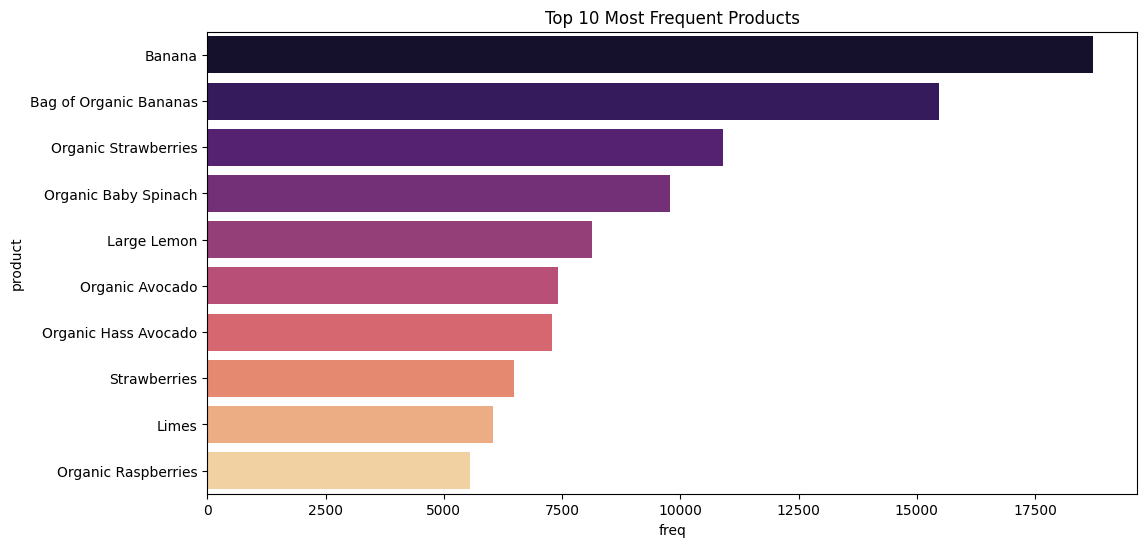

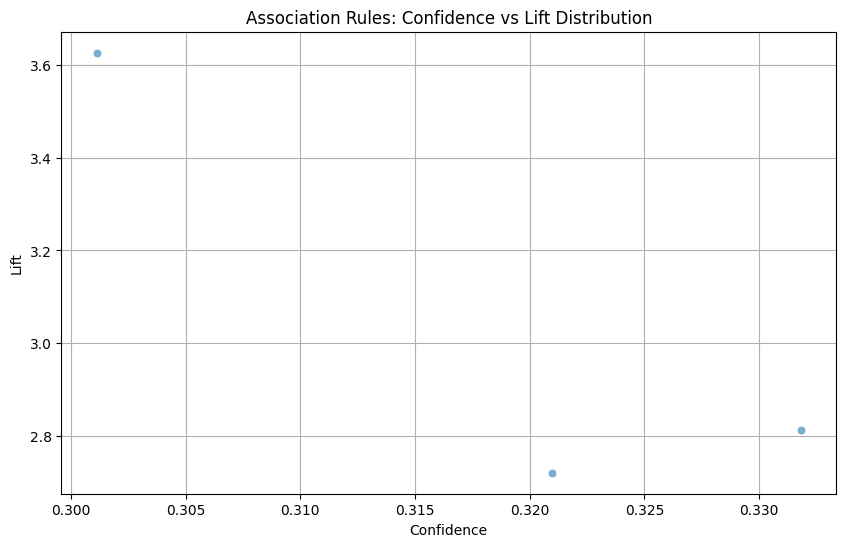

In [28]:
# Visualisasi Top 10 Produk Populer
pdf_freq = frequent_itemsets.filter(size(col("items")) == 1) \
    .withColumn("product", col("items").getItem(0)) \
    .sort(col("freq").desc()) \
    .limit(10).toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(x="freq", y="product", data=pdf_freq, palette="magma")
plt.title("Top 10 Most Frequent Products")
plt.show()

# Visualisasi Scatter Confidence vs Lift
# Only take the top 500 rules to avoid overplotting if there are too many
pdf_rules = association_rules.sort(col("confidence").desc()).limit(500).toPandas()

if not pdf_rules.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="confidence", y="lift", data=pdf_rules, alpha=0.6)
    plt.title("Association Rules: Confidence vs Lift Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Lift")
    plt.grid(True)
    plt.show()
else:
    print("No association rules found to visualize with the current parameters.")

## 8. Evaluasi Performa & Penutup
Kita mengevaluasi seberapa cepat sistem memproses data dan menyimpan hasil akhirnya.

In [29]:
# Simpan hasil sebagai file CSV tunggal (bukan folder) menggunakan Pandas
freq_pd = frequent_itemsets.withColumn("items", concat_ws("|", col("items"))).toPandas()
freq_pd.to_csv(os.path.join(OUTPUT_DIR, "frequent_itemsets.csv"), index=False)

rules_pd = association_rules.sort(col("lift").desc()) \
    .withColumn("antecedent", concat_ws("|", col("antecedent"))) \
    .withColumn("consequent", concat_ws("|", col("consequent"))) \
    .toPandas()
rules_pd.to_csv(os.path.join(OUTPUT_DIR, "association_rules.csv"), index=False)

print(f"Analisis selesai. File CSV tersimpan di: {OUTPUT_DIR}")